# Analyse des corrélations pour les ventes de la librairie LAPAGE

## Importation des librairies

In [ ]:
#Importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Chargement du fichier précedement exporté

In [ ]:
#Lien permettant d'accéder à mon Google Drive ou sont stocker mes fichiers
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importation du fichier df_clean (dataframe sans clients entreprises)
df_clean = pd.read_csv('/content/drive/MyDrive/Projet_9_Data/df_clean.csv', sep=",")

### Controle du DataFrame

In [ ]:
df_clean.head(10)

,id_prod,date,session_id,client_id,price,categ,sex,birth,age
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,11.99,0,f,1967,56
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,19.37,0,m,1960,63
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,4.50,0,m,1988,35
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,6.55,0,f,1989,34
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,16.49,0,f,1956,67
5,0_1073,2021-03-01 00:05:44.999018,s_6,c_4908,13.99,0,f,1981,42
6,0_279,2021-03-01 00:07:48.507530,s_6,c_4908,16.99,0,f,1981,42
7,1_445,2021-03-01 00:09:11.523122,s_8,c_7991,23.99,1,m,1968,55
8,1_556,2021-03-01 00:10:20.265265,s_9,c_6171,24.47,1,m,1983,40
9,1_635,2021-03-01 00:10:33.163037,s_10,c_2218,26.99,1,f,1970,53


In [ ]:
#Voir les dimensions du dataframe
df_clean.shape

(599994, 9)

## Genre d'un client et les catégories des livres achetés

Les clients et les catégories sont tout deux des variables qualitatives, je vais donc faire un test d'indépendance X²

In [ ]:
# Création d'un tableau de contingence
contingence_table = pd.crosstab(df_clean['sex'], df_clean['categ'], margins=True)
display(contingence_table)

categ,0,1,2,All
sex,,,,
f,188084,108323,15788,312195
m,174834,98160,14805,287799
All,362918,206483,30593,599994


Les hypothèses du test X² sont comme suit :


*   H0 (hypothèse nulle) : Le genre et la catégorie des livres sont indépendants, la répartition des catégories est la même quel que soit le genre

*   H1 (hypothèse alternative) : Le genre et la catégorie des livres sont dépendants, certaines catégories sont plis ou moins achetéées selon le genre




In [ ]:
df_indepencance = pd.crosstab(df_clean['sex'], df_clean['categ'])

from scipy.stats import chi2_contingency
chi2, p, dof, expected = chi2_contingency(df_indepencance)

N = df_indepencance.to_numpy().sum()
k = min(df_indepencance.shape)
cramers_v = np.sqrt((chi2 / (N * (k - 1))))

print(f"Statistique du Chi-carré: {chi2}")
print(f"Valeur p: {p}")
print(f"Degrés de liberté: {dof}")
print(f"Coefficient de Cramer's V: {cramers_v}")

Statistique du Chi-carré: 23.643905409592758
Valeur p: 7.341607713421075e-06
Degrés de liberté: 2
Coefficient de Cramer's V: 0.006277491782951116


La p-value est faible, il existe donc une dépendance entre le genre et la catégorie du livre acheté, cependant, Cramer's V qui mesure l'intensité de l'association est très faible, donc il y a dependance, mais elle est significativement nulle. Le genre n'est donc pas un levier pertinnent pour le métier.

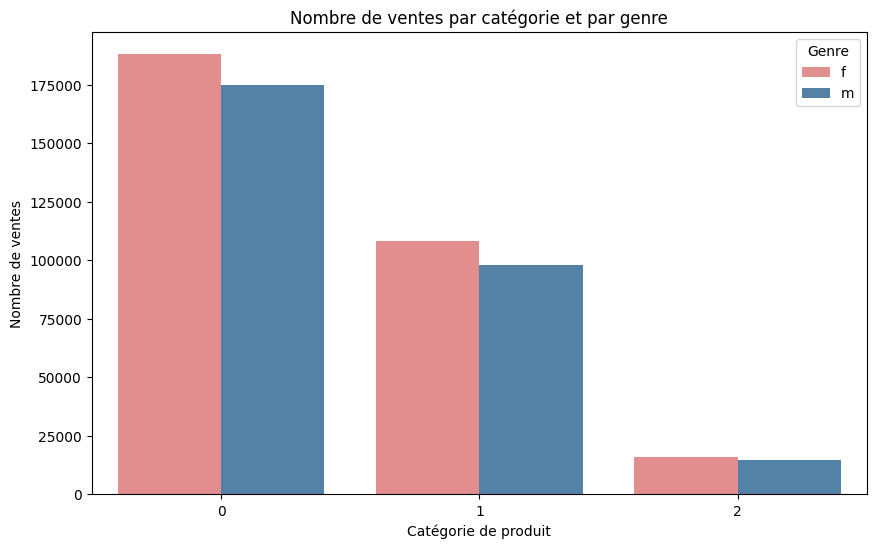

In [ ]:
#Visualisation graphique des ventes par catégorie selon le genre

plt.figure(figsize=(10, 6))
sns.countplot(
    data=df_clean,
    x='categ',
    hue='sex',
    palette={'f': 'lightcoral', 'm': 'steelblue'}
)
plt.title("Nombre de ventes par catégorie et par genre")
plt.xlabel("Catégorie de produit")
plt.ylabel("Nombre de ventes")
plt.legend(title="Genre")
plt.show()

## Age des clients et le montant total des achats

In [ ]:
#Calcul des achats totaux par client
df_achat = df_clean.groupby(['client_id', 'age'], as_index=False)['price'].sum()
df_achat.rename(columns={'price': 'total_price'}, inplace=True)
df_achat.head()

,client_id,age,total_price
0,c_1,68,584.73
1,c_10,67,1189.11
2,c_100,31,254.85
3,c_1000,57,2287.89
4,c_1001,41,1725.12


Je vais vérifier dans un premier temps la forme de la relation puis la normalité des variables


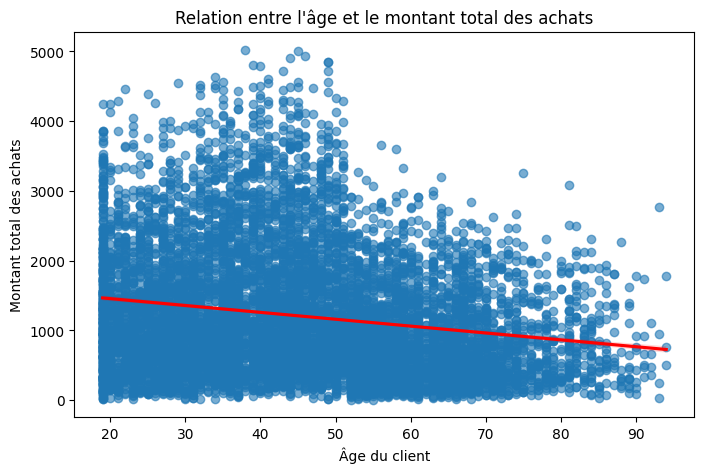

In [ ]:
# Nuage de points et droite de régression
plt.figure(figsize=(8,5))
sns.regplot(
    data=df_achat,
    x='age',
    y='total_price',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.xlabel("Âge du client")
plt.ylabel("Montant total des achats")
plt.title("Relation entre l'âge et le montant total des achats")
plt.show()

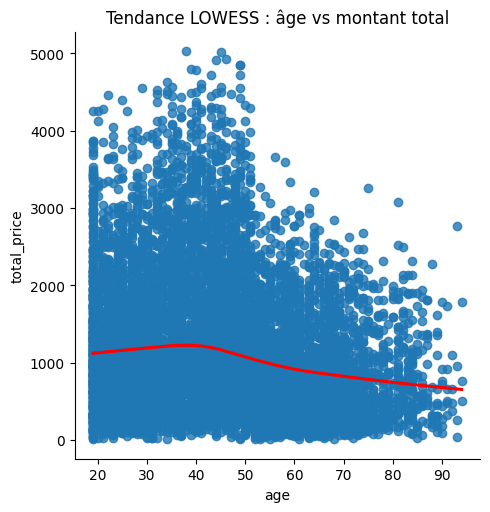

In [ ]:
#Avec lissage non linéaire
sns.lmplot(
    data=df_achat,
    x='age',
    y='total_price',
    lowess=True,
    line_kws={'color': 'red'}
)
plt.title("Tendance LOWESS : âge vs montant total")
plt.show()

In [ ]:
from scipy.stats import shapiro

#Test de normalité
p_age = shapiro(df_achat['age']).pvalue
p_price = shapiro(df_achat['total_price']).pvalue

print("p-value normalité âge :", p_age)
print("p-value normalité total_price :", p_price)

p-value normalité âge : 4.615340399594849e-39
p-value normalité total_price : 2.570700709504515e-58


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


La répartition du nuage de point et le test de Shapiro-Wilk donne des P-values très petites, inférieur à 0.05. L'hypothèse de normalité est donc rejetée pour les deux variables.

Nous allons donc utiliser le test de Spearman :

Hypothèses  
H₀ : pas de corrélation monotone entre l’âge et le montant total.
H₁ : corrélation monotone non nulle.

In [ ]:
from scipy.stats import spearmanr

rho, p_s = spearmanr(df_achat['age'], df_achat['total_price'])

print("Coefficient de Spearman :", rho)
print("p-value :", p_s)

Coefficient de Spearman : -0.18411427912775014
p-value : 2.05084717801552e-66


On rejete l'hypothèse nulle H0

Mais la encore s'il existe bien une corrélation, la p-value est faible. Les clients plus âgés ont tendance à dépenser légérement moins, mais avec un effet modeste. Ce n'est pas non plus un critère stratégique pour piloter des ventes

## Age des clients et la fréquence d'achat

In [ ]:
# Calculer la fréquence d'achat
df_freq = df_clean.groupby(['client_id', 'age']).agg(
    nb_achat=('client_id', 'count'),
    debut=('date', 'min'),
    fin=('date', 'max')
).reset_index()

# convetir 'debut' et 'fin' en date
df_freq['debut'] = pd.to_datetime(df_freq['debut'])
df_freq['fin'] = pd.to_datetime(df_freq['fin'])

#Activité en jour
df_freq['duree'] = (df_freq['fin'] - df_freq['debut']).dt.days +1

#Fréquence d'achat par mois
df_freq['freq'] = df_freq['nb_achat'] / df_freq['duree']

df_freq.head()

,client_id,age,nb_achat,debut,fin,duree,freq
0,c_1,68,41,2021-06-11 21:02:39.382765,2022-12-26 17:37:29.438136,563,0.072824
1,c_10,67,53,2021-03-21 02:50:16.551727,2022-12-28 17:04:25.834782,648,0.081790
2,c_100,31,8,2021-04-20 05:26:43.133053,2022-09-20 05:26:43.133053,519,0.015414
3,c_1000,57,125,2021-03-13 13:34:14.618755,2023-01-08 00:47:54.100237,666,0.187688
4,c_1001,41,96,2021-03-07 13:01:15.964197,2023-01-08 23:43:46.802078,673,0.142645


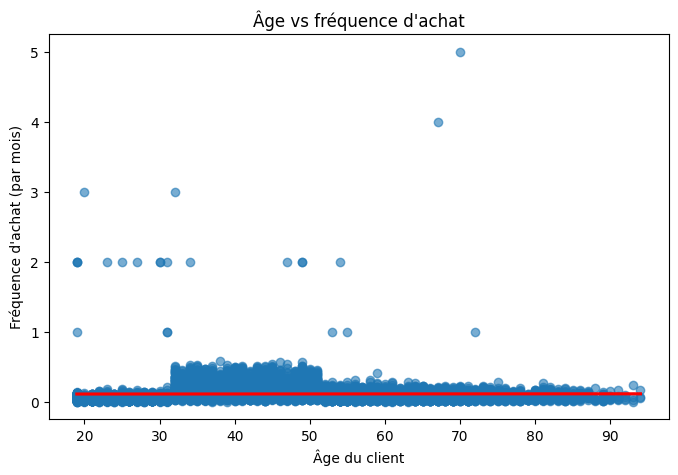

In [ ]:
#Visualisation de la relation

plt.figure(figsize=(8,5))
sns.regplot(
    data=df_freq,
    x='age',
    y='freq',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.xlabel("Âge du client")
plt.ylabel("Fréquence d'achat (par mois)")
plt.title("Âge vs fréquence d'achat")
plt.show()

In [ ]:
#Test de normalité

p_age = shapiro(df_freq['age']).pvalue
p_freq = shapiro(df_freq['freq']).pvalue

print("p-value normalité âge :", p_age)
print("p-value normalité fréquence :", p_freq)

p-value normalité âge : 4.615340399594849e-39
p-value normalité fréquence : 2.713084947415143e-95


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


Je vais utiliser le test de Spearman, les deux variables ne suivant pas une distribution normal

Hypothèses  
H₀ : pas de corrélation monotone entre l’âge et le montant total.
H₁ : corrélation monotone non nulle.

In [ ]:
#Test de corélation de Spearman

rho, p_s = spearmanr(df_freq['age'], df_freq['freq'])

print("Coefficient de Spearman :", rho)
print("p-value :", p_s)

Coefficient de Spearman : 0.11613987715716384
p-value : 3.336044841700143e-27


Corrélation toujours faible. Les clients plus agés achètent légèrement plus souvent

## Age des clients et la taille du panier moyen

In [ ]:
# Calcul du panier moyen par client
df_panier = df_clean.groupby(['client_id', 'age']).agg(
    total_price=('price', 'sum'),
    nb_achats=('price', 'count')
).reset_index()

df_panier['panier_moyen'] = df_panier['total_price'] / df_panier['nb_achats']

df_panier.head()

,client_id,age,total_price,nb_achats,panier_moyen
0,c_1,68,584.73,41,14.261707
1,c_10,67,1189.11,53,22.436038
2,c_100,31,254.85,8,31.856250
3,c_1000,57,2287.89,125,18.303120
4,c_1001,41,1725.12,96,17.970000


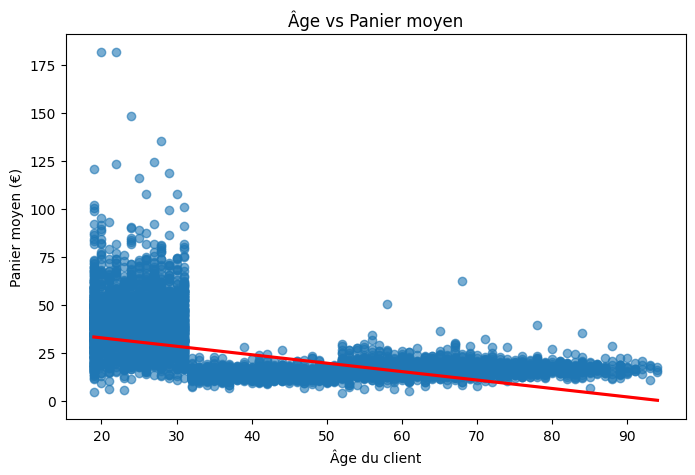

In [ ]:
#Visualisation de la relation

plt.figure(figsize=(8,5))
sns.regplot(
    data=df_panier,
    x='age',
    y='panier_moyen',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.xlabel("Âge du client")
plt.ylabel("Panier moyen (€)")
plt.title("Âge vs Panier moyen")
plt.show()


In [ ]:
#Test de normalité

p_age = shapiro(df_panier['age']).pvalue
p_panier = shapiro(df_panier['panier_moyen']).pvalue

print("p-value normalité âge :", p_age)
print("p-value normalité panier moyen :", p_panier)

p-value normalité âge : 4.615340399594849e-39
p-value normalité panier moyen : 8.426222238867478e-83


/usr/local/lib/python3.12/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8596.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
#Test de Spearman
rho, p_s = spearmanr(df_panier['age'], df_panier['panier_moyen'])

print("Coefficient de Spearman :", rho)
print("p-value :", p_s)


Coefficient de Spearman : -0.3264464493389922
p-value : 1.359473704362879e-212


C'est une corrélation modérée, plus les clients sont âgés plus leur panier moyen tend a être faible. C'est suffisemment marqué pour pouvoir être exploité dans une campagne marketing ou d'optimisation.

## Age des clients et catégorie des livres achetés

In [ ]:
#Nombre de livre achetés par catégorie et par client
df_cat = df_clean.groupby(['client_id', 'age', 'categ']).size().reset_index(name='nb_achats')
display(df_cat.head())

,client_id,age,categ,nb_achats
0,c_1,68,0,30
1,c_1,68,1,10
2,c_1,68,2,1
3,c_10,67,0,18
4,c_10,67,1,32


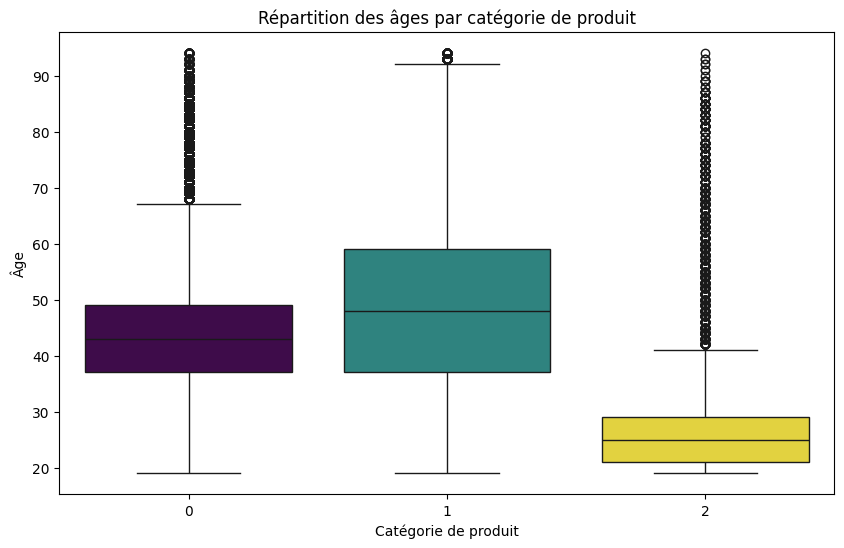

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='categ', y='age', data=df_clean, hue='categ', palette='viridis', legend=False)
plt.title('Répartition des âges par catégorie de produit')
plt.xlabel('Catégorie de produit')
plt.ylabel('Âge')
plt.show()

Voyons le test de Barlett

1.   H0 : les variances de chaque groupe sont égales si p-value > 5 %
2.   H1 : les variances de chaque groupe ne sont pas égales si p-value < 5 %.




In [ ]:
from scipy.stats import bartlett

groups = [df_clean['age'][df_clean['categ'] == c] for c in df_clean['categ'].unique()]

stat, p_bartlett = bartlett(*groups)

print(f"Statistique de Bartlett : {stat}")
print(f"p-value : {p_bartlett}")

Statistique de Bartlett : 31960.47725201393
p-value : 0.0



La p-value est inférieure à 0.05, nous rejetons l'hypothèse nulle. Cela indique qu'il existe une différence significative dans les variances des âges entre au moins deux catégories de produits.

N'ayant pas d'égalisté les conditions pour ANOVA ne sont pas respecté. Je choisi donc Kruskal-Wallis


*   H0 : Les médianes de chaque groupe sont égales si p-value > 5 %
*   H1 : Les médianes de chaque groupe ne sont pas toutes égales si p-value < 5 %



In [ ]:
from scipy.stats import kruskal

stat_kw, p_kw = kruskal(*groups)

print(f"Statistique H de Kruskal-Wallis : {stat_kw}")
print(f"p-value : {p_kw}")

Statistique H de Kruskal-Wallis : 66470.66313953145
p-value : 0.0


 La p-value est inférieure à 0.05, nous rejetons l'hypothèse nulle. Cela indique qu'il existe une différence significative dans la médiane d'âge entre au moins deux catégories de produits.

 Les catégories de livres présentent des profils d'age distincts